Training decision tree and random forest from scratch

In [119]:
from sklearn.datasets import make_classification
import numpy as np
from sklearn.metrics import f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from time import time

In [120]:
X,y = make_classification(n_samples=100, n_classes=2, random_state=42, n_features=5)

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

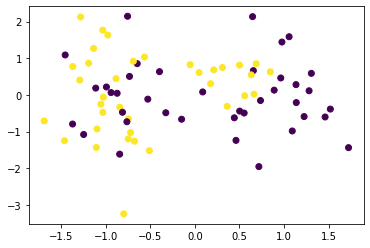

In [122]:
plt.scatter(X_train[:,0],X_train[:,4],c=y_train)

In [175]:
class TreeNode():
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf_node(self):
        return (False if self.value is None else True)


class DecisionTreeScratch():
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
    
    def fit(self, X, y, depth=0):
        if (len(np.unique(y))==1) or (depth==self.max_depth):
            a,b = np.unique(y, return_counts=True)
            if len(a)==1:
                value=a
            else:
                value = b.argmax()
            return TreeNode(value=value)
        feature, threshold = self._best_split(X,y)
        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold
        left_tree = self.fit(X[left_idx, :], y[left_idx], depth+1)
        right_tree = self.fit(X[right_idx, :], y[right_idx], depth+1)
        return TreeNode(feature, threshold, left_tree, right_tree)
    
    def _best_split(self,X,y):
        lowest_impurity = 1e10
        for feature in range(X.shape[1]):
            unique_values = np.unique(X[:, feature])
            for uv in unique_values: 
                uv = uv - 1e-4
                left_idx = X[:,feature] <= uv
                right_idx = X[:,feature] > uv
                left_size = (left_idx).sum()
                right_size = (right_idx).sum()
                if (left_size==0) or (right_size==0):
                    continue
                left_impurity = self._calculate_impurity(y[left_idx])
                right_impurity = self._calculate_impurity(y[right_idx])
                net_impurity = (1/X.shape[0])*(left_size*left_impurity + right_size*right_impurity)
                if net_impurity < lowest_impurity:
                    lowest_impurity = net_impurity
                    selected_feature = feature
                    selected_threshold = uv
        return selected_feature, selected_threshold
    
    def _calculate_impurity(self, y):
        m = y.shape[0]
        gini = 1 - ((y==0).sum()/m)**2 - ((y==1).sum()/m)**2
        return gini
    
    def predict(self, X):
        # go through tree and predict
        return 

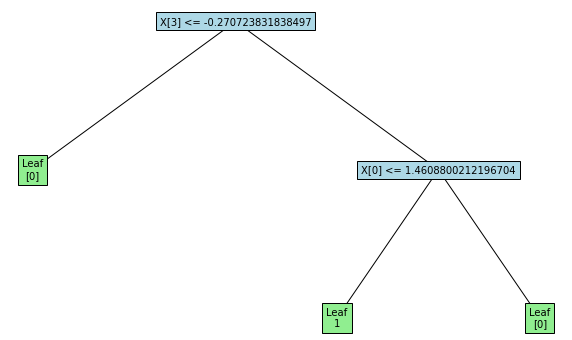

In [176]:
# Plotting helper function
def plot_tree_custom(node, depth=0, pos=None, parent=None, value=None):
    if pos is None:
        pos = (0.5, 1.0)  # Initial position
    
    # Plot the current node
    if node.is_leaf_node():
        plt.text(pos[0], pos[1], f'Leaf\n{node.value}', ha='center', va='center',
                 bbox=dict(facecolor='lightgreen', edgecolor='black'))
    else:
        plt.text(pos[0], pos[1], f'X[{node.feature}] <= {node.threshold}', ha='center', va='center',
                 bbox=dict(facecolor='lightblue', edgecolor='black'))
    
    # Draw an edge to the parent node
    if parent:
        plt.plot([parent[0], pos[0]], [parent[1], pos[1]], 'k-', lw=1)

    # Plot the left and right children recursively
    if node.left:
        left_pos = (pos[0] - 1 / 2**(depth + 1), pos[1] - 0.1)  # Shift to the left
        plot_tree_custom(node.left, depth + 1, left_pos, pos)

    if node.right:
        right_pos = (pos[0] + 1 / 2**(depth + 1), pos[1] - 0.1)  # Shift to the right
        plot_tree_custom(node.right, depth + 1, right_pos, pos)

# Example of fitting the tree and plotting
dt = DecisionTreeScratch(max_depth=2)
model = dt.fit(X_train, y_train)

# Initialize the plot
plt.figure(figsize=(10, 6))
plt.axis('off')

# Plot the tree from the root node
plot_tree_custom(model)

# Show the plot
plt.show()


[Text(0.4, 0.8333333333333334, 'X[3] <= -0.301\ngini = 0.499\nsamples = 75\nvalue = [39, 36]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 35\nvalue = [35, 0]'),
 Text(0.6, 0.5, 'X[2] <= 1.608\ngini = 0.18\nsamples = 40\nvalue = [4, 36]'),
 Text(0.4, 0.16666666666666666, 'gini = 0.053\nsamples = 37\nvalue = [1, 36]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]')]

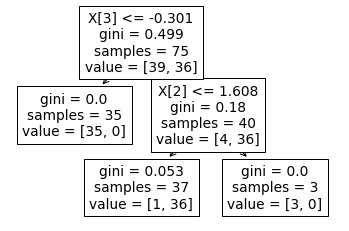

In [174]:
dtc = DecisionTreeClassifier(max_depth=2)
dtc.fit(X_train, y_train)
plot_tree(dtc)